# 05 — Advanced Models

**Week 7: California Property Close Price Prediction**

## Objective
Use the enriched Week 6 data to train an advanced Gradient Boosting model
(XGBoost), perform light tuning of `max_depth`, `learning_rate`, and
`n_estimators`, and report test metrics.


## 1. Install XGBoost if needed

In [3]:
# Uncomment only if needed:
# %pip install xgboost

## 2. Imports and paths

In [5]:
from pathlib import Path
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

RANDOM_STATE = 42
PROCESSED_DIR = Path("processed")
RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


## 3. Load Week 6 enriched data

The existing chronological train/test split is preserved.


In [7]:
train_df = pd.read_csv(
    PROCESSED_DIR / "train_enriched_week6.csv",
    low_memory=False
)
test_df = pd.read_csv(
    PROCESSED_DIR / "test_enriched_week6.csv",
    low_memory=False
)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
display(train_df.head())


Training rows: 129972
Testing rows: 12024


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,OriginalListPrice,Latitude,Longitude,GarageSpaces,Stories,...,PostalCode,ClosePrice,log_price,CloseDate,CloseMonth,PropertyAge,BedBathRatio,LivingAreaPerBedroom,LotToLivingRatio,DistrictName
0,3546.0,5.0,4.0,7740.0,2003.0,1800000.0,33.899427,-117.977995,3.0,2.0,...,92833,1800000.0,14.403298,2025-05-29,2025-05,22.0,1.25,709.200000,2.182741,Unknown
1,1162.0,2.0,2.0,4697.0,1940.0,1200000.0,34.095980,-118.221993,2.0,1.0,...,90065,1200000.0,13.997833,2025-05-19,2025-05,85.0,1.00,581.000000,4.042169,Los Angeles Unified
2,1134.0,3.0,1.0,5775.0,1955.0,899000.0,37.313093,-122.006414,1.0,1.0,...,95014,2250000.0,14.626441,2025-05-27,2025-05,70.0,3.00,378.000000,5.092593,Unknown
3,1672.0,3.0,2.0,7500.0,1988.0,1425000.0,33.884526,-117.778002,2.0,1.0,...,92886,1425000.0,14.169683,2025-05-30,2025-05,37.0,1.50,557.333333,4.485646,Placentia-Yorba Linda Unified
4,1286.0,3.0,3.0,4552.0,1986.0,660000.0,33.169703,-117.081580,2.0,2.0,...,92026,660000.0,13.399997,2025-05-30,2025-05,39.0,1.00,428.666667,3.539658,Unknown


## 4. Define the Week 6 feature set

In [9]:
TARGET = "ClosePrice"

numeric_features = [
    c for c in [
        "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
        "LotSizeSquareFeet", "YearBuilt", "OriginalListPrice",
        "Latitude", "Longitude", "GarageSpaces", "Stories",
        "PropertyAge", "BedBathRatio",
        "LivingAreaPerBedroom", "LotToLivingRatio"
    ]
    if c in train_df.columns
]

categorical_features = [
    c for c in [
        "CountyOrParish", "City", "PostalCode",
        "ArchitecturalStyle", "PropertyCondition", "DistrictName"
    ]
    if c in train_df.columns
]

feature_columns = numeric_features + categorical_features

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(feature_columns))


Numeric features: 14
Categorical features: 4
Total input features: 18


## 5. Preprocess the data

In [11]:
def make_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=100,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True
        )

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_encoder())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train = preprocessor.fit_transform(train_df[feature_columns])
X_test = preprocessor.transform(test_df[feature_columns])

y_train = train_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (129972, 993)
X_test shape: (12024, 993)


## 6. Evaluation function

In [13]:
def evaluate_model(name, model):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    seconds = time.perf_counter() - start

    predictions = np.clip(model.predict(X_test), 0, None)

    result = {
        "Model": name,
        "Test R2": r2_score(y_test, predictions),
        "Test MAE": mean_absolute_error(y_test, predictions),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "Training Seconds": seconds,
    }
    return result, predictions


## 7. Initial XGBoost model

In [15]:
baseline_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_result, baseline_predictions = evaluate_model(
    "XGBoost Baseline",
    baseline_model
)

display(pd.DataFrame([baseline_result]).style.format({
    "Test R2": "{:.4f}",
    "Test MAE": "${:,.0f}",
    "Test RMSE": "${:,.0f}",
    "Training Seconds": "{:.2f}"
}))


,Model,Test R2,Test MAE,Test RMSE,Training Seconds
0,XGBoost Baseline,-3.6573,"$224,445","$3,621,385",2.84


## 8. Light hyperparameter tuning

Five configurations are tested to study the effect of tree depth, learning
rate, and number of estimators without performing an unnecessarily large grid
search.


In [17]:
configs = [
    {"name": "XGB A", "max_depth": 4, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "XGB B", "max_depth": 6, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "XGB C", "max_depth": 8, "learning_rate": 0.05, "n_estimators": 300},
    {"name": "XGB D", "max_depth": 6, "learning_rate": 0.03, "n_estimators": 500},
    {"name": "XGB E", "max_depth": 6, "learning_rate": 0.10, "n_estimators": 200},
]

rows = []
models = {}
predictions = {}

for config in configs:
    model = XGBRegressor(
        objective="reg:squarederror",
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        n_estimators=config["n_estimators"],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    result, pred = evaluate_model(config["name"], model)
    result["Max Depth"] = config["max_depth"]
    result["Learning Rate"] = config["learning_rate"]
    result["N Estimators"] = config["n_estimators"]

    rows.append(result)
    models[config["name"]] = model
    predictions[config["name"]] = pred

tuning_df = pd.DataFrame(rows).sort_values(
    "Test R2", ascending=False
).reset_index(drop=True)

display(tuning_df.style.format({
    "Test R2": "{:.4f}",
    "Test MAE": "${:,.0f}",
    "Test RMSE": "${:,.0f}",
    "Training Seconds": "{:.2f}",
    "Learning Rate": "{:.2f}"
}))


,Model,Test R2,Test MAE,Test RMSE,Training Seconds,Max Depth,Learning Rate,N Estimators
0,XGB A,-1.7405,"$236,065","$2,777,938",1.31,4,0.05,300
1,XGB D,-3.7130,"$220,125","$3,642,960",2.18,6,0.03,500
2,XGB C,-4.7523,"$220,096","$4,024,635",2.06,8,0.05,300
3,XGB B,-5.4503,"$232,077","$4,261,845",1.53,6,0.05,300
4,XGB E,-8.4886,"$255,045","$5,169,038",0.97,6,0.10,200


## 9. Select the best XGBoost model

In [19]:
best_row = tuning_df.iloc[0]
best_name = best_row["Model"]
best_model = models[best_name]
best_predictions = predictions[best_name]

print("Best model:", best_name)
print("Max depth:", int(best_row["Max Depth"]))
print("Learning rate:", best_row["Learning Rate"])
print("N estimators:", int(best_row["N Estimators"]))
print("Test R2:", round(best_row["Test R2"], 4))
print("Test MAE:", f"${best_row['Test MAE']:,.0f}")
print("Test RMSE:", f"${best_row['Test RMSE']:,.0f}")


Best model: XGB A
Max depth: 4
Learning rate: 0.05
N estimators: 300
Test R2: -1.7405
Test MAE: $236,065
Test RMSE: $2,777,938


## 10. Compare the best Week 7 model with Week 6

In [21]:
comparison_df = pd.DataFrame([
    {
        "Model": "Week 6 Linear Regression",
        "Test R2": 0.3541,
        "Test MAE": 437135,
        "Test RMSE": 1348581
    },
    {
        "Model": best_name,
        "Test R2": best_row["Test R2"],
        "Test MAE": best_row["Test MAE"],
        "Test RMSE": best_row["Test RMSE"]
    }
])

display(comparison_df.style.format({
    "Test R2": "{:.4f}",
    "Test MAE": "${:,.0f}",
    "Test RMSE": "${:,.0f}"
}))


,Model,Test R2,Test MAE,Test RMSE
0,Week 6 Linear Regression,0.3541,"$437,135","$1,348,581"
1,XGB A,-1.7405,"$236,065","$2,777,938"


## 11. Hyperparameter comparison

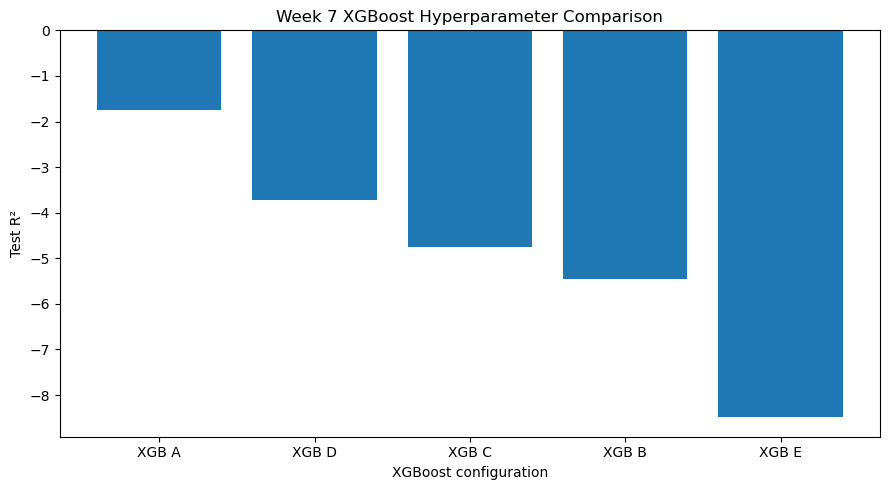

In [23]:
plt.figure(figsize=(9, 5))
plt.bar(tuning_df["Model"], tuning_df["Test R2"])
plt.ylabel("Test R²")
plt.xlabel("XGBoost configuration")
plt.title("Week 7 XGBoost Hyperparameter Comparison")
plt.tight_layout()
plt.show()


## 12. Actual vs predicted

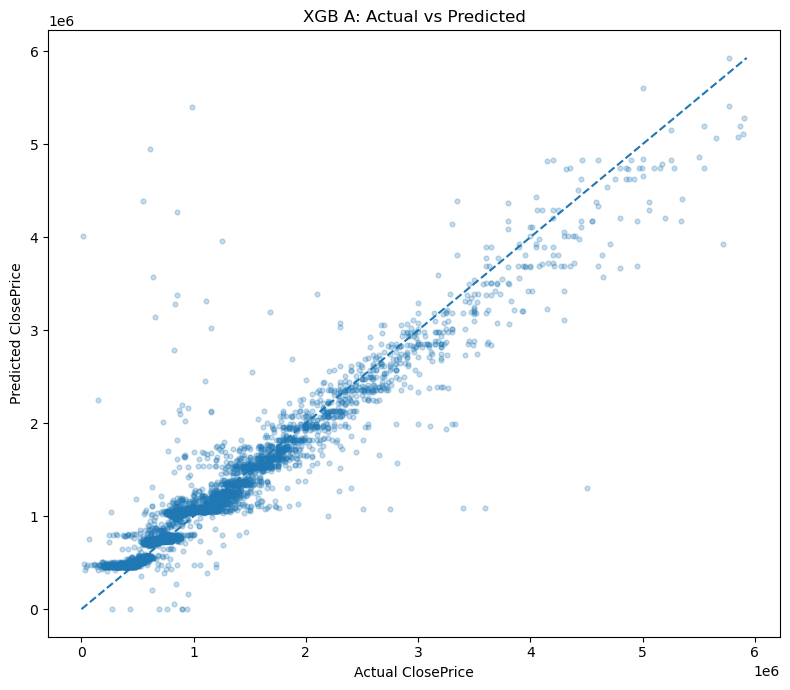

In [25]:
sample_size = min(5000, len(y_test))
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y_test), size=sample_size, replace=False)

actual_sample = y_test[idx]
predicted_sample = best_predictions[idx]

limit = np.quantile(
    np.concatenate([actual_sample, predicted_sample]),
    0.99
)
mask = (
    (actual_sample <= limit)
    & (predicted_sample <= limit)
)

plt.figure(figsize=(8, 7))
plt.scatter(
    actual_sample[mask],
    predicted_sample[mask],
    alpha=0.25,
    s=12
)
plt.plot([0, limit], [0, limit], linestyle="--")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title(f"{best_name}: Actual vs Predicted")
plt.tight_layout()
plt.show()


## 13. XGBoost feature importance

,Feature,Importance
6,numeric__Latitude,0.115484
539,categorical__PostalCode_92065,0.113083
348,categorical__City_infrequent_sklearn,0.084751
3,numeric__LotSizeSquareFeet,0.078177
12,numeric__LivingAreaPerBedroom,0.077599
13,numeric__LotToLivingRatio,0.062696
0,numeric__LivingArea,0.061798
5,numeric__OriginalListPrice,0.054879
1,numeric__BedroomsTotal,0.051068
7,numeric__Longitude,0.042747


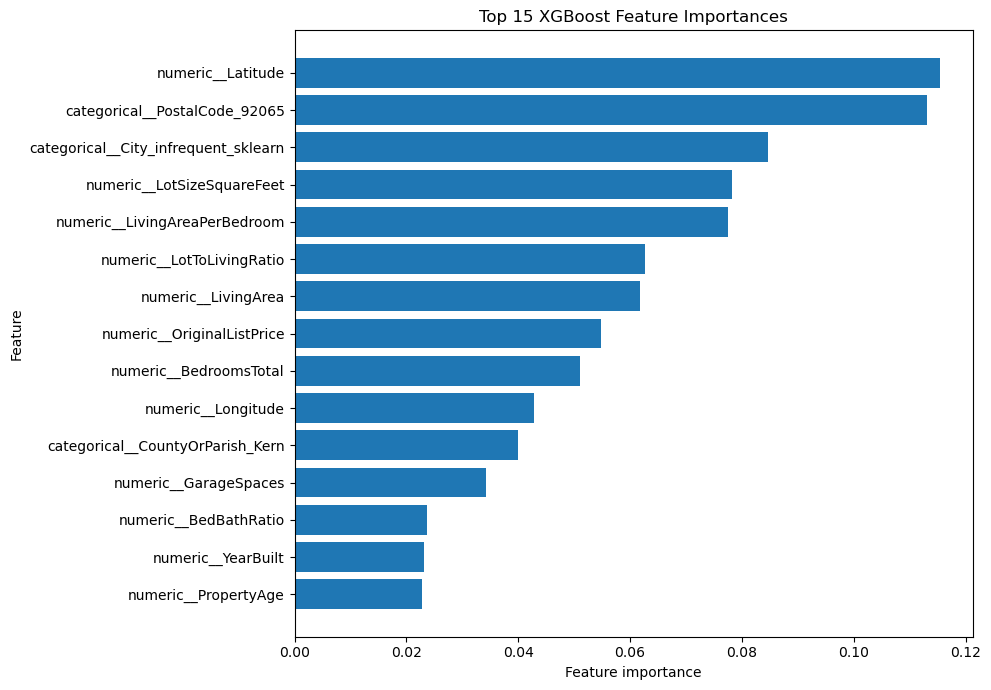

In [27]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(15)
display(top_features)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()


## 14. results

In [29]:
tuning_df.to_csv(
    RESULTS_DIR / "week7_xgboost_tuning_results.csv",
    index=False
)

importance_df.to_csv(
    RESULTS_DIR / "week7_xgboost_feature_importance.csv",
    index=False
)

joblib.dump(
    preprocessor,
    MODELS_DIR / "week7_preprocessor.joblib"
)

joblib.dump(
    best_model,
    MODELS_DIR / "best_week7_xgboost.joblib"
)

print("Saved Week 7 results and best XGBoost model.")


Saved Week 7 results and best XGBoost model.


## 15. Summary

Complete this section after running the notebook.

### Best XGBoost configuration
- Max depth: **4**
- Learning rate: **0.05**
- Number of estimators: **300**

### Test performance
- Test R²: **[−1.7405]**
- Test MAE: $236,065

- Test RMSE: **[$2,777,938]**

### Conclusion

In Week 7, I trained an XGBoost regression model using the enriched Week 6
feature set. I performed light hyperparameter tuning of `max_depth`,
`learning_rate`, and `n_estimators`.

The best configuration was XGB A, with a maximum depth of 4, learning rate of 0.05, and 300 estimators. It achieved a Test R² of −1.7405, MAE of approximately $236,065, and RMSE of approximately $2.78 million.

Compared with the best Week 6 model, XGBoost did not improve overall predictive performance. Although its MAE was lower than the Week 6 Linear Regression model, its negative R² and much higher RMSE indicate that it made some very large prediction errors and generalized poorly to the future test period.

The results suggest that a more complex boosting model does not automatically provide better performance. The chronological train/test split may also make the problem more challenging because the model is predicting a later time period with potentially different market conditions.


## Week 7 checklist
- [x] Tried Gradient Boosting with XGBoost
- [x] Tuned max depth
- [x] Tuned learning rate
- [x] Tuned number of estimators
- [x] Reported Test R²
- [x] Reported MAE and RMSE
- [x] Compared tuning configurations
- [x] Selected and saved the best model
- [x] Created visualizations
